In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [2]:
# Load the dataset
file_path = '/content/drive/MyDrive/Crime Prediction Datasets/Final crime stats dataset.csv'  # Update with your actual file path
df = pd.read_csv(file_path)

Dataset Shape: (255, 21)

First few rows:
  Unit Name  Year  Dacoity  Robbery  Murder  Speedy Trial  Riot  \
0       DMP  2010       47      220     245           363     3   
1       CMP  2010       16      108      94            31     7   
2       KMP  2010        3        9      29            25     0   
3       RMP  2010        4       20      21             9    15   
4       BMP  2010        8       12      19            21     0   

   Woman & Child Repression  Kidnapping  Police Assault  ...  Theft  \
0                      1370         139             155  ...   1915   
1                       455          37              31  ...    314   
2                       153          11               4  ...     91   
3                       157           9              12  ...    106   
4                       112           6               8  ...     83   

   Other Cases  Recovery_Case_Arms_Act  Recovery_Case_Explosive  \
0         7228                     518                       

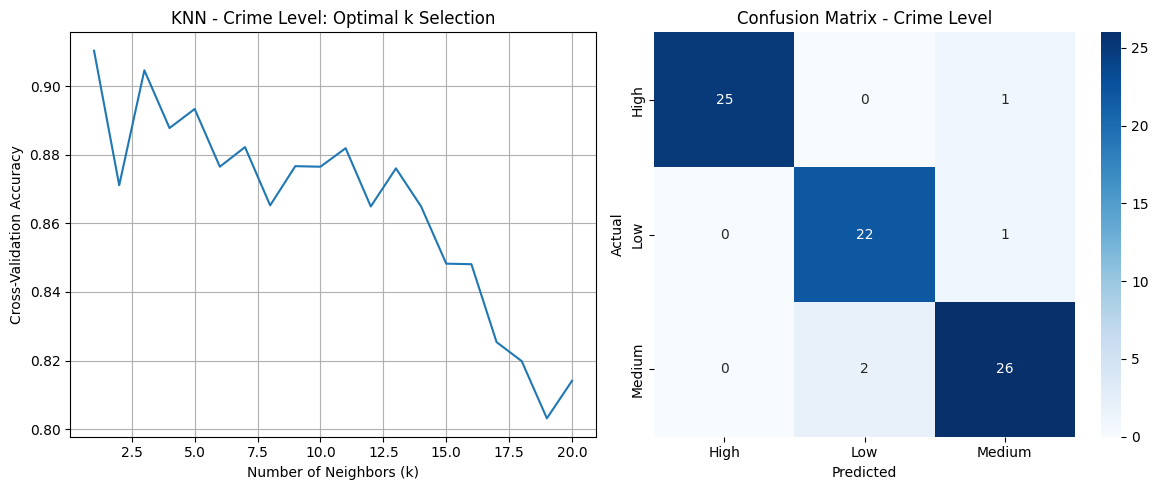


KNN FOR RECOVERY LEVEL PREDICTION
Training set size: (178, 17)
Test set size: (77, 17)

--- Finding Optimal k for Recovery Level ---
Optimal k for Recovery Level: 4
Best CV Accuracy: 0.8938

--- Recovery Level Prediction Results ---
Accuracy: 0.9091
Precision: 0.9144
Recall: 0.9091
F1-Score: 0.9103

Detailed Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.93      0.96        27
         Low       0.91      0.87      0.89        23
      Medium       0.83      0.93      0.88        27

    accuracy                           0.91        77
   macro avg       0.91      0.91      0.91        77
weighted avg       0.91      0.91      0.91        77



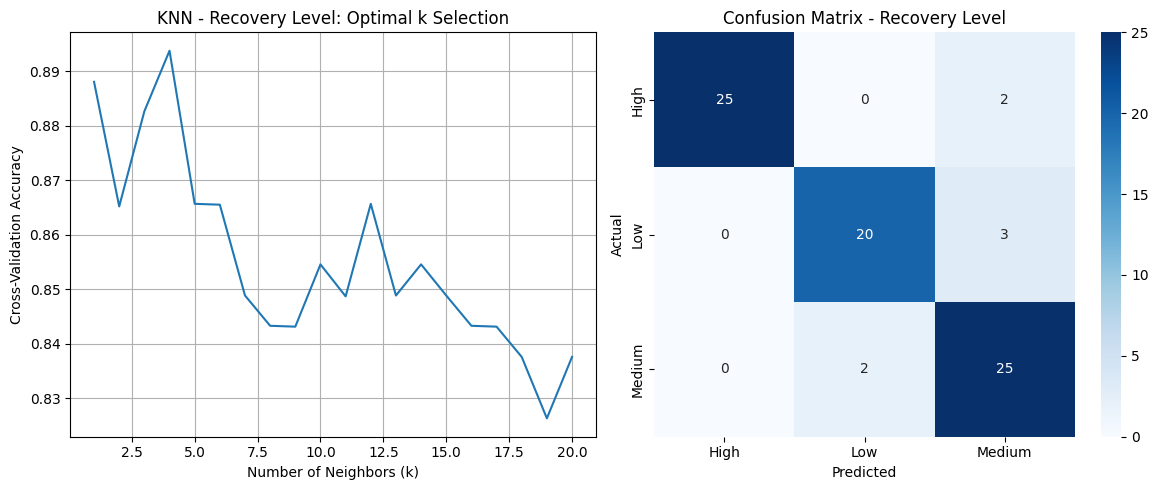


MODEL COMPARISON SUMMARY
      Metric  Crime_Level  Recovery_Level
0   Accuracy       0.9481          0.9091
1  Precision       0.9491          0.9144
2     Recall       0.9481          0.9091
3   F1-Score       0.9483          0.9103

FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features for Crime Level Prediction:
                     feature  importance
5   Woman & Child Repression    0.129870
3               Speedy Trial    0.106494
12   Recovery_Case_Explosive    0.090909
2                     Murder    0.079221
10               Other Cases    0.079221
16            Recovery_Score    0.077922
15               Crime_Score    0.077922
13   Recovery_Case_Narcotics    0.076623
6                 Kidnapping    0.068831
4                       Riot    0.066234

Top 10 Most Important Features for Recovery Level Prediction:
                     feature  importance
13   Recovery_Case_Narcotics    0.136364
16            Recovery_Score    0.133766
5   Woman & Child Repression    0.1038

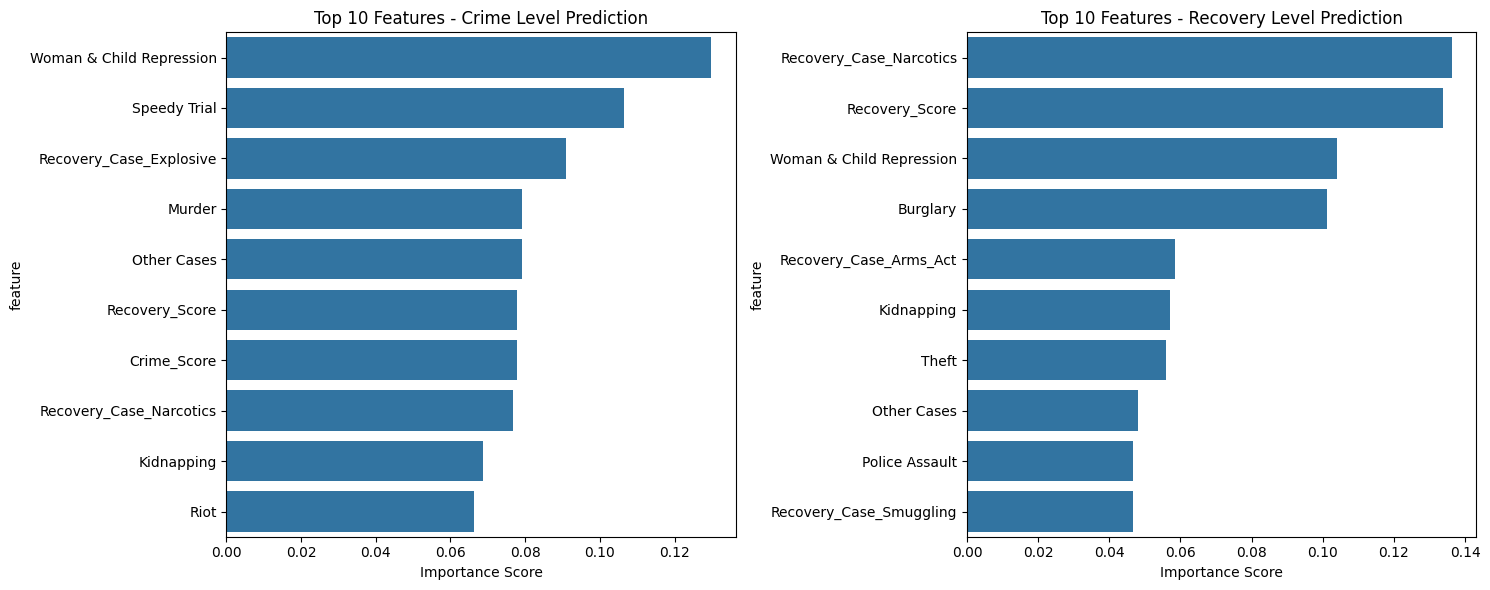


HYPERPARAMETER TUNING WITH GRIDSEARCH
Best parameters for Crime Level: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Best cross-validation score: 0.9330158730158731
Final Test Accuracy with tuned model: 0.9091

ANALYSIS COMPLETE!


In [3]:
# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Data Preprocessing
print("\n=== DATA PREPROCESSING ===")

# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Encode categorical target variables
le_crime = LabelEncoder()
le_recovery = LabelEncoder()

df['Crime_Level_Encoded'] = le_crime.fit_transform(df['Crime_Level'])
df['Recovery_Level_Encoded'] = le_recovery.fit_transform(df['Recovery_Level'])

print("\nCrime Level Encoding:")
for i, level in enumerate(le_crime.classes_):
    print(f"{level}: {i}")

print("\nRecovery Level Encoding:")
for i, level in enumerate(le_recovery.classes_):
    print(f"{level}: {i}")

# Select features for modeling (excluding non-numeric and target columns)
exclude_columns = ['Unit Name', 'Year', 'Crime_Level', 'Recovery_Level', 'Crime_Level_Encoded', 'Recovery_Level_Encoded']
feature_columns = [col for col in df.columns if col not in exclude_columns]

print(f"\nNumber of feature columns: {len(feature_columns)}")
print("Feature columns:", feature_columns)

# KNN for Crime Level Prediction
print("\n" + "="*50)
print("KNN FOR CRIME LEVEL PREDICTION")
print("="*50)

# Prepare features and target for Crime Level
X_crime = df[feature_columns]
y_crime = df['Crime_Level_Encoded']

# Split the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_crime, y_crime, test_size=0.3, random_state=42, stratify=y_crime
)

# Scale the features
scaler_crime = StandardScaler()
X_train_c_scaled = scaler_crime.fit_transform(X_train_c)
X_test_c_scaled = scaler_crime.transform(X_test_c)

print(f"Training set size: {X_train_c_scaled.shape}")
print(f"Test set size: {X_test_c_scaled.shape}")

# Find optimal k using cross-validation
print("\n--- Finding Optimal k for Crime Level ---")
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_c_scaled, y_train_c, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot CV scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, cv_scores)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN - Crime Level: Optimal k Selection')
plt.grid(True)

# Find the best k
optimal_k_crime = k_range[np.argmax(cv_scores)]
print(f"Optimal k for Crime Level: {optimal_k_crime}")
print(f"Best CV Accuracy: {max(cv_scores):.4f}")

# Train KNN with optimal k
knn_crime = KNeighborsClassifier(n_neighbors=optimal_k_crime)
knn_crime.fit(X_train_c_scaled, y_train_c)

# Make predictions
y_pred_crime = knn_crime.predict(X_test_c_scaled)

# Calculate metrics
accuracy_crime = accuracy_score(y_test_c, y_pred_crime)
precision_crime = precision_score(y_test_c, y_pred_crime, average='weighted')
recall_crime = recall_score(y_test_c, y_pred_crime, average='weighted')
f1_crime = f1_score(y_test_c, y_pred_crime, average='weighted')

print("\n--- Crime Level Prediction Results ---")
print(f"Accuracy: {accuracy_crime:.4f}")
print(f"Precision: {precision_crime:.4f}")
print(f"Recall: {recall_crime:.4f}")
print(f"F1-Score: {f1_crime:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test_c, y_pred_crime, target_names=le_crime.classes_))

# Confusion Matrix
plt.subplot(1, 2, 2)
cm_crime = confusion_matrix(y_test_c, y_pred_crime)
sns.heatmap(cm_crime, annot=True, fmt='d', cmap='Blues',
           xticklabels=le_crime.classes_, yticklabels=le_crime.classes_)
plt.title('Confusion Matrix - Crime Level')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# KNN for Recovery Level Prediction
print("\n" + "="*50)
print("KNN FOR RECOVERY LEVEL PREDICTION")
print("="*50)

# Prepare features and target for Recovery Level
X_recovery = df[feature_columns]
y_recovery = df['Recovery_Level_Encoded']

# Split the data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_recovery, y_recovery, test_size=0.3, random_state=42, stratify=y_recovery
)

# Scale the features
scaler_recovery = StandardScaler()
X_train_r_scaled = scaler_recovery.fit_transform(X_train_r)
X_test_r_scaled = scaler_recovery.transform(X_test_r)

print(f"Training set size: {X_train_r_scaled.shape}")
print(f"Test set size: {X_test_r_scaled.shape}")

# Find optimal k using cross-validation
print("\n--- Finding Optimal k for Recovery Level ---")
cv_scores_recovery = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_r_scaled, y_train_r, cv=5, scoring='accuracy')
    cv_scores_recovery.append(scores.mean())

# Plot CV scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, cv_scores_recovery)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN - Recovery Level: Optimal k Selection')
plt.grid(True)

# Find the best k
optimal_k_recovery = k_range[np.argmax(cv_scores_recovery)]
print(f"Optimal k for Recovery Level: {optimal_k_recovery}")
print(f"Best CV Accuracy: {max(cv_scores_recovery):.4f}")

# Train KNN with optimal k
knn_recovery = KNeighborsClassifier(n_neighbors=optimal_k_recovery)
knn_recovery.fit(X_train_r_scaled, y_train_r)

# Make predictions
y_pred_recovery = knn_recovery.predict(X_test_r_scaled)

# Calculate metrics
accuracy_recovery = accuracy_score(y_test_r, y_pred_recovery)
precision_recovery = precision_score(y_test_r, y_pred_recovery, average='weighted')
recall_recovery = recall_score(y_test_r, y_pred_recovery, average='weighted')
f1_recovery = f1_score(y_test_r, y_pred_recovery, average='weighted')

print("\n--- Recovery Level Prediction Results ---")
print(f"Accuracy: {accuracy_recovery:.4f}")
print(f"Precision: {precision_recovery:.4f}")
print(f"Recall: {recall_recovery:.4f}")
print(f"F1-Score: {f1_recovery:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test_r, y_pred_recovery, target_names=le_recovery.classes_))

# Confusion Matrix
plt.subplot(1, 2, 2)
cm_recovery = confusion_matrix(y_test_r, y_pred_recovery)
sns.heatmap(cm_recovery, annot=True, fmt='d', cmap='Blues',
           xticklabels=le_recovery.classes_, yticklabels=le_recovery.classes_)
plt.title('Confusion Matrix - Recovery Level')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Compare both models
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Crime_Level': [accuracy_crime, precision_crime, recall_crime, f1_crime],
    'Recovery_Level': [accuracy_recovery, precision_recovery, recall_recovery, f1_recovery]
})

print(comparison_df.round(4))

# Feature importance analysis (using permutation importance)
from sklearn.inspection import permutation_importance

print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# For Crime Level
print("\nTop 10 Most Important Features for Crime Level Prediction:")
result_crime = permutation_importance(knn_crime, X_test_c_scaled, y_test_c, n_repeats=10, random_state=42)
feature_importance_crime = pd.DataFrame({
    'feature': feature_columns,
    'importance': result_crime.importances_mean
}).sort_values('importance', ascending=False)

print(feature_importance_crime.head(10))

# For Recovery Level
print("\nTop 10 Most Important Features for Recovery Level Prediction:")
result_recovery = permutation_importance(knn_recovery, X_test_r_scaled, y_test_r, n_repeats=10, random_state=42)
feature_importance_recovery = pd.DataFrame({
    'feature': feature_columns,
    'importance': result_recovery.importances_mean
}).sort_values('importance', ascending=False)

print(feature_importance_recovery.head(10))

# Visualize feature importance
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=feature_importance_crime.head(10), x='importance', y='feature')
plt.title('Top 10 Features - Crime Level Prediction')
plt.xlabel('Importance Score')

plt.subplot(1, 2, 2)
sns.barplot(data=feature_importance_recovery.head(10), x='importance', y='feature')
plt.title('Top 10 Features - Recovery Level Prediction')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Advanced: Hyperparameter tuning with GridSearchCV
print("\n" + "="*50)
print("HYPERPARAMETER TUNING WITH GRIDSEARCH")
print("="*50)

# For Crime Level
param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_c_scaled, y_train_c)

print("Best parameters for Crime Level:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Final evaluation with best model
best_knn_crime = grid_search.best_estimator_
y_pred_best_crime = best_knn_crime.predict(X_test_c_scaled)
final_accuracy_crime = accuracy_score(y_test_c, y_pred_best_crime)
print(f"Final Test Accuracy with tuned model: {final_accuracy_crime:.4f}")

# Save the models (optional)
import joblib

models = {
    'knn_crime': knn_crime,
    'knn_recovery': knn_recovery,
    'scaler_crime': scaler_crime,
    'scaler_recovery': scaler_recovery,
    'label_encoder_crime': le_crime,
    'label_encoder_recovery': le_recovery
}

# Uncomment to save models
# joblib.dump(models, '/content/drive/My Drive/knn_crime_models.pkl')
# print("Models saved successfully!")

print("\n" + "="*50)
print("ANALYSIS COMPLETE!")
print("="*50)